# Caso paso a paso: reglas de asociación en un supermercado

Este notebook desarrolla un **caso completo y guiado** de reglas de asociación.

La idea es que el lector ya haya leído las definiciones de:

- soporte;
- confianza;
- lift.

Por eso, aquí no partimos desde la teoría abstracta, sino desde un caso concreto.

Trabajaremos con un supermercado pequeño que quiere analizar si ciertos productos se compran juntos.

## 1. Situación del caso

Un supermercado quiere entender mejor el comportamiento de compra de sus clientes.

En particular, quiere responder preguntas como:

> ¿Qué productos suelen comprarse juntos?

> ¿Existen combinaciones de productos que podrían servir para promociones, recomendaciones o ubicación en góndolas?

Para simplificar, analizaremos un conjunto pequeño de transacciones. Cada transacción representa una compra realizada por un cliente.

## 2. Datos del caso

Supongamos que el supermercado registró las siguientes 20 transacciones.

Cada fila corresponde a una compra distinta.

In [1]:
import pandas as pd

transacciones = [
    ["Café", "Pan", "Leche"],
    ["Café", "Pan"],
    ["Café", "Pan", "Mantequilla"],
    ["Café", "Galletas"],
    ["Café", "Pan", "Azúcar"],
    ["Café", "Pan", "Leche"],
    ["Café", "Leche"],
    ["Café", "Pan"],
    ["Pan", "Leche"],
    ["Pan", "Mantequilla"],
    ["Pan", "Galletas"],
    ["Pan", "Leche", "Azúcar"],
    ["Leche", "Galletas"],
    ["Leche", "Azúcar"],
    ["Mantequilla", "Pan"],
    ["Café", "Galletas", "Azúcar"],
    ["Pan", "Galletas"],
    ["Café", "Pan", "Mantequilla"],
    ["Leche", "Pan"],
    ["Azúcar", "Galletas"]
]

df_transacciones = pd.DataFrame({
    "Transacción": [f"T{i+1}" for i in range(len(transacciones))],
    "Productos": [", ".join(t) for t in transacciones]
})

df_transacciones

,Transacción,Productos
0,T1,"Café, Pan, Leche"
1,T2,"Café, Pan"
2,T3,"Café, Pan, Mantequilla"
3,T4,"Café, Galletas"
4,T5,"Café, Pan, Azúcar"
5,T6,"Café, Pan, Leche"
6,T7,"Café, Leche"
7,T8,"Café, Pan"
8,T9,"Pan, Leche"
9,T10,"Pan, Mantequilla"


## 3. Lectura inicial de los datos

Antes de calcular métricas, conviene mirar los datos en lenguaje simple.

Por ejemplo:

- La transacción `T1` contiene `Café`, `Pan` y `Leche`.
- La transacción `T2` contiene `Café` y `Pan`.
- La transacción `T4` contiene `Café` y `Galletas`.

En reglas de asociación no nos interesa el orden de los productos dentro de una compra.  
Nos interesa saber **qué productos aparecen juntos**.

## 4. Pregunta que analizaremos

Para que el caso sea fácil de seguir, nos concentraremos primero en una regla específica:

$$
\{\text{Café}\} \rightarrow \{\text{Pan}\}
$$

Esta regla se lee así:

> Si una compra contiene café, entonces también podría contener pan.

La pregunta práctica es:

> Cuando una persona compra café, ¿es más probable que también compre pan?

Para responder usaremos, paso a paso:

1. soporte de `{Café}`;
2. soporte de `{Pan}`;
3. soporte conjunto de `{Café, Pan}`;
4. confianza de `{Café} → {Pan}`;
5. lift de `{Café} → {Pan}`.

## 5. Convertir las transacciones en una matriz binaria

Para calcular reglas de asociación, es común transformar las transacciones en una matriz de presencia o ausencia.

En esta matriz:

- `1` significa que el producto aparece en la transacción;
- `0` significa que el producto no aparece en la transacción.

Esto permite contar fácilmente cuántas veces aparece cada producto o combinación de productos.

In [2]:
productos = sorted(set(producto for compra in transacciones for producto in compra))

matriz = pd.DataFrame([
    {producto: int(producto in compra) for producto in productos}
    for compra in transacciones
])

matriz.insert(0, "Transacción", [f"T{i+1}" for i in range(len(transacciones))])
matriz

,Transacción,Azúcar,Café,Galletas,Leche,Mantequilla,Pan
0,T1,0,1,0,1,0,1
1,T2,0,1,0,0,0,1
2,T3,0,1,0,0,1,1
3,T4,0,1,1,0,0,0
4,T5,1,1,0,0,0,1
5,T6,0,1,0,1,0,1
6,T7,0,1,0,1,0,0
7,T8,0,1,0,0,0,1
8,T9,0,0,0,1,0,1
9,T10,0,0,0,0,1,1


## 6. Contar apariciones individuales

Ahora contaremos cuántas transacciones contienen cada producto.

Esto todavía no genera reglas, pero ayuda a entender qué productos son frecuentes.

In [3]:
conteos_productos = matriz[productos].sum().sort_values(ascending=False)

df_conteos = pd.DataFrame({
    "Producto": conteos_productos.index,
    "Transacciones que lo contienen": conteos_productos.values,
    "Soporte": conteos_productos.values / len(transacciones)
})

df_conteos

,Producto,Transacciones que lo contienen,Soporte
0,Pan,14,0.70
1,Café,10,0.50
2,Leche,8,0.40
3,Galletas,6,0.30
4,Azúcar,5,0.25
5,Mantequilla,4,0.20


## 7. Soporte de `{Café}`

Primero calculamos el soporte de `{Café}`.

El soporte responde:

> ¿En qué porcentaje de todas las compras aparece café?

En este caso, `{Café}` aparece en 10 de las 20 transacciones.

Entonces:

$$
\text{soporte}(\{\text{Café}\}) = \frac{10}{20} = 0.50
$$

Esto significa que `{Café}` aparece en el **50%** de las compras.

In [4]:
total_transacciones = len(transacciones)

conteo_cafe = matriz["Café"].sum()
soporte_cafe = conteo_cafe / total_transacciones

conteo_cafe, soporte_cafe

print(f"Total de transacciones: {total_transacciones}")
print(f"Transacciones con Café: {conteo_cafe}")
print(f"Soporte de Café: {soporte_cafe:.2f}")
print(f"Soporte de Café en porcentaje: {soporte_cafe:.0%}")

Total de transacciones: 20
Transacciones con Café: 10
Soporte de Café: 0.50
Soporte de Café en porcentaje: 50%


## 8. Soporte de `{Pan}`

Ahora calculamos el soporte de `{Pan}`.

Esto responde:

> ¿En qué porcentaje de todas las compras aparece pan?

En este caso, `{Pan}` aparece en 13 de las 20 transacciones.

Entonces:

$$
\text{soporte}(\{\text{Pan}\}) = \frac{13}{20} = 0.65
$$

Esto significa que `{Pan}` aparece en el **65%** de las compras.

Este valor será importante más adelante para calcular el **lift**.

In [5]:
conteo_pan = matriz["Pan"].sum()
soporte_pan = conteo_pan / total_transacciones

print(f"Total de transacciones: {total_transacciones}")
print(f"Transacciones con Pan: {conteo_pan}")
print(f"Soporte de Pan: {soporte_pan:.2f}")
print(f"Soporte de Pan en porcentaje: {soporte_pan:.0%}")

Total de transacciones: 20
Transacciones con Pan: 14
Soporte de Pan: 0.70
Soporte de Pan en porcentaje: 70%


## 9. Soporte conjunto de `{Café, Pan}`

Ahora calculamos cuántas transacciones contienen **ambos productos al mismo tiempo**.

Esto responde:

> ¿En qué porcentaje de todas las compras aparecen juntos café y pan?

En este caso, `{Café, Pan}` aparece en 7 de las 20 transacciones.

Entonces:

$$
\text{soporte}(\{\text{Café}, \text{Pan}\}) = \frac{7}{20} = 0.35
$$

Esto significa que café y pan aparecen juntos en el **35%** de las compras.

In [6]:
matriz["Café_y_Pan"] = matriz["Café"] & matriz["Pan"]

conteo_cafe_pan = matriz["Café_y_Pan"].sum()
soporte_cafe_pan = conteo_cafe_pan / total_transacciones

print(f"Total de transacciones: {total_transacciones}")
print(f"Transacciones con Café y Pan: {conteo_cafe_pan}")
print(f"Soporte conjunto de Café y Pan: {soporte_cafe_pan:.2f}")
print(f"Soporte conjunto en porcentaje: {soporte_cafe_pan:.0%}")

Total de transacciones: 20
Transacciones con Café y Pan: 7
Soporte conjunto de Café y Pan: 0.35
Soporte conjunto en porcentaje: 35%


## 10. Ver las transacciones donde aparecen juntos

Para que el cálculo no quede como una fórmula aislada, revisemos cuáles son las transacciones donde aparecen juntos `{Café}` y `{Pan}`.

In [7]:
df_cafe_pan = df_transacciones[matriz["Café_y_Pan"].astype(bool)]
df_cafe_pan

,Transacción,Productos
0,T1,"Café, Pan, Leche"
1,T2,"Café, Pan"
2,T3,"Café, Pan, Mantequilla"
4,T5,"Café, Pan, Azúcar"
5,T6,"Café, Pan, Leche"
7,T8,"Café, Pan"
17,T18,"Café, Pan, Mantequilla"


## 11. Confianza de `{Café} → {Pan}`

Ahora calculamos la confianza de la regla:

$$
\{\text{Café}\} \rightarrow \{\text{Pan}\}
$$

La confianza responde:

> De las compras que contienen café, ¿en cuántas también aparece pan?

Sabemos que:

| Conteo | Valor |
|---|---:|
| Transacciones con `{Café}` | 10 |
| Transacciones con `{Café, Pan}` | 7 |

Entonces:

$$
\text{confianza}(\{\text{Café}\} \rightarrow \{\text{Pan}\}) =
\frac{7}{10} = 0.70
$$

Esto significa que, cuando una compra contiene café, en el **70%** de los casos también contiene pan.

In [8]:
confianza_cafe_pan = soporte_cafe_pan / soporte_cafe

print("Regla analizada: Café → Pan")
print(f"Transacciones con Café: {conteo_cafe}")
print(f"Transacciones con Café y Pan: {conteo_cafe_pan}")
print(f"Confianza: {confianza_cafe_pan:.2f}")
print(f"Confianza en porcentaje: {confianza_cafe_pan:.0%}")

Regla analizada: Café → Pan
Transacciones con Café: 10
Transacciones con Café y Pan: 7
Confianza: 0.70
Confianza en porcentaje: 70%


## 12. Interpretación de la confianza

La confianza de la regla `{Café} → {Pan}` es **0.70**.

Esto se puede leer así:

> De cada 10 compras que incluyen café, 7 también incluyen pan.

A primera vista parece una regla útil, porque el porcentaje es relativamente alto.

Sin embargo, todavía falta una pregunta importante:

> ¿Ese 70% es realmente interesante, o simplemente ocurre porque pan es un producto muy frecuente?

Para responder eso usamos el **lift**.

## 13. Lift de `{Café} → {Pan}`

El lift compara la confianza de la regla con la frecuencia general del consecuente.

En este caso, el consecuente es `{Pan}`.

Sabemos que:

| Métrica | Valor |
|---|---:|
| Confianza de `{Café} → {Pan}` | 0.70 |
| Soporte de `{Pan}` | 0.65 |

Entonces:

$$
\text{lift}(\{\text{Café}\} \rightarrow \{\text{Pan}\}) =
\frac{0.70}{0.65} = 1.08
$$

El lift es mayor que 1, por lo tanto existe una asociación positiva.

Pero el valor está cerca de 1, entonces la asociación no es muy fuerte.

In [9]:
lift_cafe_pan = confianza_cafe_pan / soporte_pan

print("Regla analizada: Café → Pan")
print(f"Confianza de Café → Pan: {confianza_cafe_pan:.2f}")
print(f"Soporte de Pan: {soporte_pan:.2f}")
print(f"Lift: {lift_cafe_pan:.2f}")

if lift_cafe_pan > 1:
    print("Interpretación: asociación positiva. Café aumenta la aparición de Pan.")
elif lift_cafe_pan == 1:
    print("Interpretación: independencia aproximada. Café no cambia la aparición de Pan.")
else:
    print("Interpretación: asociación negativa. Café reduce la aparición de Pan.")

Regla analizada: Café → Pan
Confianza de Café → Pan: 0.70
Soporte de Pan: 0.70
Lift: 1.00
Interpretación: independencia aproximada. Café no cambia la aparición de Pan.


## 14. Interpretación del lift

El lift obtenido es aproximadamente **1.08**.

Esto significa que:

> Comprar café aumenta ligeramente la probabilidad de comprar pan.

La palabra clave es **ligeramente**.

¿Por qué?

Porque pan ya aparece en el 65% de todas las compras.  
Cuando miramos solo las compras con café, pan aparece en el 70%.

La diferencia existe, pero no es enorme.

Por eso, la regla `{Café} → {Pan}` puede ser considerada positiva, pero no especialmente fuerte.

## 15. Resumen de la regla analizada

Ahora reunimos los valores principales de la regla `{Café} → {Pan}`.

In [10]:
resumen_regla = pd.DataFrame({
    "Elemento": [
        "Total de transacciones",
        "Transacciones con Café",
        "Transacciones con Pan",
        "Transacciones con Café y Pan",
        "Soporte de Café",
        "Soporte de Pan",
        "Soporte de Café y Pan",
        "Confianza Café → Pan",
        "Lift Café → Pan"
    ],
    "Valor": [
        total_transacciones,
        conteo_cafe,
        conteo_pan,
        conteo_cafe_pan,
        round(soporte_cafe, 2),
        round(soporte_pan, 2),
        round(soporte_cafe_pan, 2),
        round(confianza_cafe_pan, 2),
        round(lift_cafe_pan, 2)
    ]
})

resumen_regla

,Elemento,Valor
0,Total de transacciones,20.00
1,Transacciones con Café,10.00
2,Transacciones con Pan,14.00
3,Transacciones con Café y Pan,7.00
4,Soporte de Café,0.50
5,Soporte de Pan,0.70
6,Soporte de Café y Pan,0.35
7,Confianza Café → Pan,0.70
8,Lift Café → Pan,1.00


## 16. Comparar con la regla inversa

Una regla de asociación tiene dirección.

Esto significa que:

$$
\{\text{Café}\} \rightarrow \{\text{Pan}\}
$$

no es necesariamente igual a:

$$
\{\text{Pan}\} \rightarrow \{\text{Café}\}
$$

Ahora analizaremos la regla inversa para ver la diferencia.

## 17. Confianza de `{Pan} → {Café}`

La regla inversa es:

$$
\{\text{Pan}\} \rightarrow \{\text{Café}\}
$$

Esta regla responde:

> De las compras que contienen pan, ¿en cuántas también aparece café?

Sabemos que:

| Conteo | Valor |
|---|---:|
| Transacciones con `{Pan}` | 13 |
| Transacciones con `{Café, Pan}` | 7 |

Entonces:

$$
\text{confianza}(\{\text{Pan}\} \rightarrow \{\text{Café}\}) =
\frac{7}{13} \approx 0.54
$$

Esto significa que, cuando una compra contiene pan, en aproximadamente el **54%** de los casos también contiene café.

In [11]:
confianza_pan_cafe = soporte_cafe_pan / soporte_pan
lift_pan_cafe = confianza_pan_cafe / soporte_cafe

print("Regla analizada: Pan → Café")
print(f"Transacciones con Pan: {conteo_pan}")
print(f"Transacciones con Café y Pan: {conteo_cafe_pan}")
print(f"Confianza de Pan → Café: {confianza_pan_cafe:.2f}")
print(f"Confianza en porcentaje: {confianza_pan_cafe:.0%}")
print(f"Soporte de Café: {soporte_cafe:.2f}")
print(f"Lift de Pan → Café: {lift_pan_cafe:.2f}")

if lift_pan_cafe > 1:
    print("Interpretación: asociación positiva. Pan aumenta la aparición de Café.")
elif lift_pan_cafe == 1:
    print("Interpretación: independencia aproximada. Pan no cambia la aparición de Café.")
else:
    print("Interpretación: asociación negativa. Pan reduce la aparición de Café.")

Regla analizada: Pan → Café
Transacciones con Pan: 14
Transacciones con Café y Pan: 7
Confianza de Pan → Café: 0.50
Confianza en porcentaje: 50%
Soporte de Café: 0.50
Lift de Pan → Café: 1.00
Interpretación: independencia aproximada. Pan no cambia la aparición de Café.


## 18. Comparación entre ambas direcciones

Ahora comparamos las dos reglas:

1. `{Café} → {Pan}`
2. `{Pan} → {Café}`

Ambas usan el mismo soporte conjunto, porque en ambos casos hablamos de las transacciones donde aparecen café y pan juntos.

Pero la confianza cambia porque cambia el antecedente.

In [12]:
comparacion_direcciones = pd.DataFrame({
    "Regla": ["Café → Pan", "Pan → Café"],
    "Soporte conjunto": [soporte_cafe_pan, soporte_cafe_pan],
    "Confianza": [confianza_cafe_pan, confianza_pan_cafe],
    "Lift": [lift_cafe_pan, lift_pan_cafe]
})

comparacion_direcciones.round(2)

,Regla,Soporte conjunto,Confianza,Lift
0,Café → Pan,0.35,0.7,1.0
1,Pan → Café,0.35,0.5,1.0


## 19. Interpretación de la comparación

La regla `{Café} → {Pan}` tiene mayor confianza que `{Pan} → {Café}`.

Esto ocurre porque:

- Café aparece en 10 transacciones.
- Pan aparece en 13 transacciones.
- Ambos aparecen juntos en 7 transacciones.

Entonces:

$$
\frac{7}{10} = 0.70
$$

pero:

$$
\frac{7}{13} \approx 0.54
$$

En palabras simples:

> Es más común que una compra con café también tenga pan, que una compra con pan también tenga café.

Esto muestra que las reglas de asociación tienen dirección y que no basta con decir “café y pan aparecen juntos”.

## 20. Generar algunas reglas adicionales

Hasta ahora analizamos una sola relación.

Ahora generaremos reglas simples entre pares de productos para comparar cuáles parecen más interesantes.

Para mantener el ejemplo fácil, solo analizaremos reglas de la forma:

$$
\{A\} \rightarrow \{B\}
$$

donde `A` y `B` son productos individuales.

In [13]:
from itertools import permutations

reglas = []

for antecedente, consecuente in permutations(productos, 2):
    conteo_antecedente = matriz[antecedente].sum()
    conteo_consecuente = matriz[consecuente].sum()
    conteo_ambos = ((matriz[antecedente] == 1) & (matriz[consecuente] == 1)).sum()

    soporte_antecedente = conteo_antecedente / total_transacciones
    soporte_consecuente = conteo_consecuente / total_transacciones
    soporte_ambos = conteo_ambos / total_transacciones

    if soporte_antecedente > 0:
        confianza = soporte_ambos / soporte_antecedente
    else:
        confianza = 0

    if soporte_consecuente > 0:
        lift = confianza / soporte_consecuente
    else:
        lift = 0

    reglas.append({
        "Regla": f"{antecedente} → {consecuente}",
        "Antecedente": antecedente,
        "Consecuente": consecuente,
        "Soporte conjunto": soporte_ambos,
        "Confianza": confianza,
        "Lift": lift,
        "Conteo conjunto": conteo_ambos
    })

df_reglas = pd.DataFrame(reglas)
df_reglas.sort_values(["Lift", "Confianza", "Soporte conjunto"], ascending=False).round(2)

,Regla,Antecedente,Consecuente,Soporte conjunto,Confianza,Lift,Conteo conjunto
24,Mantequilla → Pan,Mantequilla,Pan,0.20,1.00,1.43,4
29,Pan → Mantequilla,Pan,Mantequilla,0.20,0.29,1.43,4
1,Azúcar → Galletas,Azúcar,Galletas,0.10,0.40,1.33,2
10,Galletas → Azúcar,Galletas,Azúcar,0.10,0.33,1.33,2
9,Café → Pan,Café,Pan,0.35,0.70,1.00,7
26,Pan → Café,Pan,Café,0.35,0.50,1.00,7
21,Mantequilla → Café,Mantequilla,Café,0.10,0.50,1.00,2
2,Azúcar → Leche,Azúcar,Leche,0.10,0.40,1.00,2
15,Leche → Azúcar,Leche,Azúcar,0.10,0.25,1.00,2
8,Café → Mantequilla,Café,Mantequilla,0.10,0.20,1.00,2


## 21. Filtrar reglas con criterios mínimos

En un caso real no se revisan todas las reglas.

Se suelen aplicar umbrales mínimos, por ejemplo:

- soporte conjunto mínimo: 0.20;
- confianza mínima: 0.50;
- lift mayor que 1.00.

Esto permite quedarse solo con reglas que sean frecuentes, razonablemente confiables y con asociación positiva.

In [14]:
soporte_minimo = 0.20
confianza_minima = 0.50
lift_minimo = 1.00

reglas_filtradas = df_reglas[
    (df_reglas["Soporte conjunto"] >= soporte_minimo) &
    (df_reglas["Confianza"] >= confianza_minima) &
    (df_reglas["Lift"] > lift_minimo)
].sort_values(["Lift", "Confianza"], ascending=False)

reglas_filtradas.round(2)

,Regla,Antecedente,Consecuente,Soporte conjunto,Confianza,Lift,Conteo conjunto
24,Mantequilla → Pan,Mantequilla,Pan,0.2,1.0,1.43,4


## 22. Interpretar las reglas filtradas

Las reglas filtradas son candidatas a ser interpretadas.

Una regla con buen lift puede indicar una relación más interesante que una regla con alta confianza pero lift cercano a 1.

Por ejemplo:

- una regla con confianza alta dice que el consecuente aparece muchas veces cuando aparece el antecedente;
- una regla con lift alto dice que esa aparición es mayor que lo esperado por la frecuencia general del consecuente.

Por eso, conviene mirar soporte, confianza y lift al mismo tiempo.

## 23. Visualización simple de las reglas

Para facilitar la comparación, graficaremos las reglas filtradas usando:

- eje X: soporte conjunto;
- eje Y: confianza;
- tamaño del punto: lift.

Esto ayuda a ver qué reglas combinan frecuencia, confianza e interés.

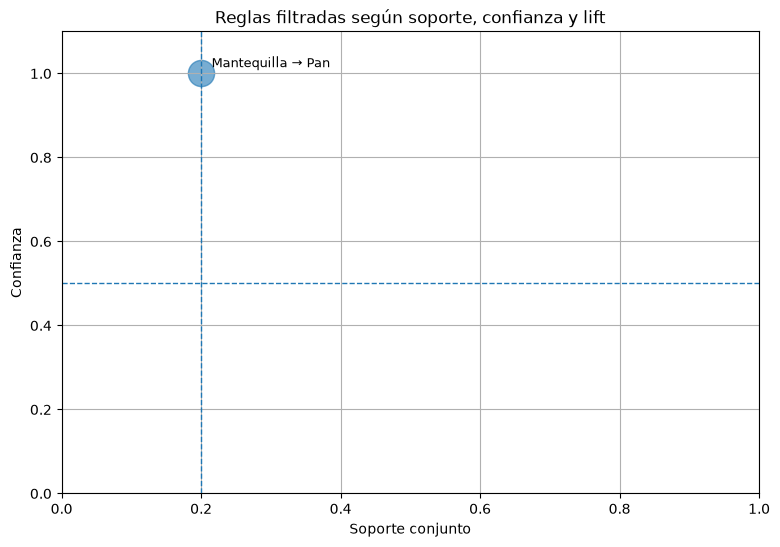

In [15]:
import matplotlib.pyplot as plt

# Verificar si existen reglas filtradas
if reglas_filtradas.empty:
    print("No hay reglas que cumplan los filtros definidos.")
else:
    plt.figure(figsize=(9, 6))

    x = reglas_filtradas["Soporte conjunto"]
    y = reglas_filtradas["Confianza"]

    # El tamaño del punto representa el lift
    sizes = reglas_filtradas["Lift"] * 250

    plt.scatter(
        x,
        y,
        s=sizes,
        alpha=0.6
    )

    # Etiquetas de cada regla
    for _, row in reglas_filtradas.iterrows():
        plt.text(
            row["Soporte conjunto"] + 0.015,
            row["Confianza"] + 0.015,
            row["Regla"],
            fontsize=9
        )

    plt.xlabel("Soporte conjunto")
    plt.ylabel("Confianza")
    plt.title("Reglas filtradas según soporte, confianza y lift")

    # Escalas fijas para que el gráfico sea más fácil de interpretar
    plt.xlim(0, 1)
    plt.ylim(0, 1.1)

    # Líneas de referencia
    plt.axhline(y=0.5, linestyle="--", linewidth=1)
    plt.axvline(x=0.2, linestyle="--", linewidth=1)

    plt.grid(True)
    plt.show()

## 23.1 ¿Cómo interpretar este gráfico?

Este gráfico resume las reglas de asociación que pasaron los filtros definidos anteriormente.

Cada punto representa una regla. En este caso, solo aparece una regla filtrada:

$$
\{\text{Mantequilla}\} \rightarrow \{\text{Pan}\}
$$

El gráfico usa tres elementos para representar la calidad de la regla:

| Elemento del gráfico | Qué representa |
|---|---|
| Eje X | Soporte conjunto |
| Eje Y | Confianza |
| Tamaño del punto | Lift |


### Interpretación del eje X: soporte conjunto

El eje X muestra el **soporte conjunto** de la regla.

En este caso, el punto está cerca de:

$$
0.20
$$

Esto significa que `{Mantequilla}` y `{Pan}` aparecen juntos en aproximadamente el **20%** de todas las transacciones.

En palabras simples:

> De cada 20 compras, alrededor de 4 contienen mantequilla y pan juntos.

### Interpretación del eje Y: confianza

El eje Y muestra la **confianza** de la regla.

En este caso, la confianza es:

$$
1.00
$$

Esto significa que, cada vez que aparece `{Mantequilla}`, también aparece `{Pan}`.

En palabras simples:

> En este conjunto de datos, todas las compras que contienen mantequilla también contienen pan.

Por eso la regla:

$$
\{\text{Mantequilla}\} \rightarrow \{\text{Pan}\}
$$

tiene una confianza del **100%**.


### Interpretación del tamaño del punto: lift

El tamaño del punto representa el **lift**.

El lift indica si la relación entre antecedente y consecuente es más fuerte que lo esperado por la frecuencia general del consecuente.

En este caso, el punto corresponde a una regla que pasó el filtro de lift mayor que 1, por lo tanto existe una asociación positiva.

Esto significa que:

> La presencia de mantequilla aumenta la probabilidad de que también aparezca pan.


### Interpretación general

La regla filtrada puede interpretarse así:

> Cuando una compra contiene mantequilla, también contiene pan con una confianza muy alta.

Sin embargo, también hay que mirar el soporte. Aunque la confianza es alta, el soporte conjunto es cercano a 0.20. Esto indica que la regla no aparece en la mayoría de las transacciones, sino en una parte limitada del conjunto de datos.

Por eso, la conclusión debe ser cuidadosa:

> La relación `{Mantequilla} → {Pan}` parece fuerte dentro de las compras donde aparece mantequilla, pero se basa en una cantidad relativamente pequeña de transacciones.


### Conclusión práctica

Para el supermercado, esta regla podría sugerir que mantequilla y pan tienen sentido como productos relacionados.

Por ejemplo, el supermercado podría considerar:

- ubicarlos cerca;
- hacer una promoción conjunta;
- recomendar pan cuando un cliente compra mantequilla.

Pero como el conjunto de datos es pequeño, esta conclusión debería confirmarse con más transacciones antes de tomar una decisión comercial importante.

## 24. Decisión práctica

Supongamos que el supermercado quiere tomar una decisión simple.

A partir del análisis, podría considerar:

- ubicar productos relacionados cerca;
- crear promociones combinadas;
- recomendar un producto cuando el cliente compra otro;
- estudiar con más datos si la relación se mantiene.

Para la regla `{Café} → {Pan}`, la interpretación sería:

> Cuando un cliente compra café, existe una probabilidad relativamente alta de que también compre pan.

Pero el lift está cerca de 1, por lo que la relación positiva es moderada.  
Esto sugiere que la regla puede ser útil, pero no debería tomarse como una conclusión fuerte sin más datos.

## 25. Cierre del caso

Este caso mostró el flujo básico para analizar reglas de asociación:

1. partir de transacciones;
2. transformar las compras en una matriz binaria;
3. contar apariciones individuales;
4. contar apariciones conjuntas;
5. calcular soporte;
6. calcular confianza;
7. calcular lift;
8. comparar reglas;
9. filtrar reglas;
10. interpretar resultados en el contexto del problema.

La idea más importante es que una regla no debe evaluarse con una sola métrica.

Una buena interpretación considera simultáneamente:

- si la regla aparece con suficiente frecuencia;
- si tiene una confianza razonable;
- si el lift muestra una asociación mayor que la esperada por azar;
- si la regla tiene sentido para el problema de negocio.

## 26. Actividades sugeridas

Para practicar, se pueden responder las siguientes preguntas:

1. ¿Qué regla tiene el mayor lift?
2. ¿Qué regla tiene la mayor confianza?
3. ¿La regla con mayor confianza es también la regla más interesante?
4. ¿Qué ocurre si se aumenta el soporte mínimo a 0.30?
5. ¿Qué ocurre si se exige una confianza mínima de 0.70?
6. ¿Qué decisión práctica tomarías con las reglas encontradas?

Estas preguntas ayudan a pasar de calcular métricas a interpretar resultados.